# Import

In [1]:

import random
import networkx as nx


In [2]:
from game_sim import GameState

In [3]:
from game_sim import Action

In [4]:
import game_sim

# Demo

## Checking node data access

In [5]:
demo_game_state = GameState(start_node=11)

In [6]:
demo_game_state.graph.nodes[12]["event information"]

{'name': 'Racrans Festung',
 'description': 'Racrans Festung stellt die am besten befestigte Burg in der Grafschaft Itreg dar. Einst war sie ein wichtiger taktischer Stützpunkt, seit Beginn der langen Jahre des Friedens vor 324 Jahren, ist sie vorallem bekannst geworden durch ihrer außergewöhlichen Festmähler, aber auch für Gelehrte ist ihre Bibliothek ein Anziehungspunkt.',
 'area': 1}

In [7]:
demo_game_state.graph.nodes[12]["option information"]

[{'text': 'Festmahl gegen Eintrittsgeld genießen',
  'description': 'Eine teurer Angelegenheit - aber du wolltest schon immer einen solchen Schmaus erleben.',
  'values': [0, 0, 2],
  'cost': 40,
  'positive': {'result': 'Diese Aramiksumme hat sich wirklich gelohnt. Das Essen ist köstlich, die Unterhaltung exzellent und die Gesellschaft anregend.',
   'description': 'Du verlässt Racrans Festung am nächsten Morgen gen Norden mit neu geknüpften Kontakten.',
   'changes': [0, 0, 1],
   'moneyChange': -40,
   'new node': 16},
  'negative': {'result': 'Diese Aramiksumme hat sich wirklich gelohnt. Das Essen ist köstlich, die Unterhaltung exzellent, jedoch fühlen sich einige Gäste durch deine Anwesenheit gestört und werfen dich aus der Festung',
   'description': 'Du verlässt Racrans Festung gen Norden.',
   'changes': [0, 0, 0],
   'moneyChange': -40,
   'new node': 16}},
 {'text': 'Türsteher bitten, dich ohne Eintrittsgeld an dem Festmahl teilnehmen zu lassen',
  'description': 'Warum bezah

## Checking taking action

In [8]:
game_state_demo = GameState(start_node=5, strength=0, knowledge=2, charme=3, money=40)

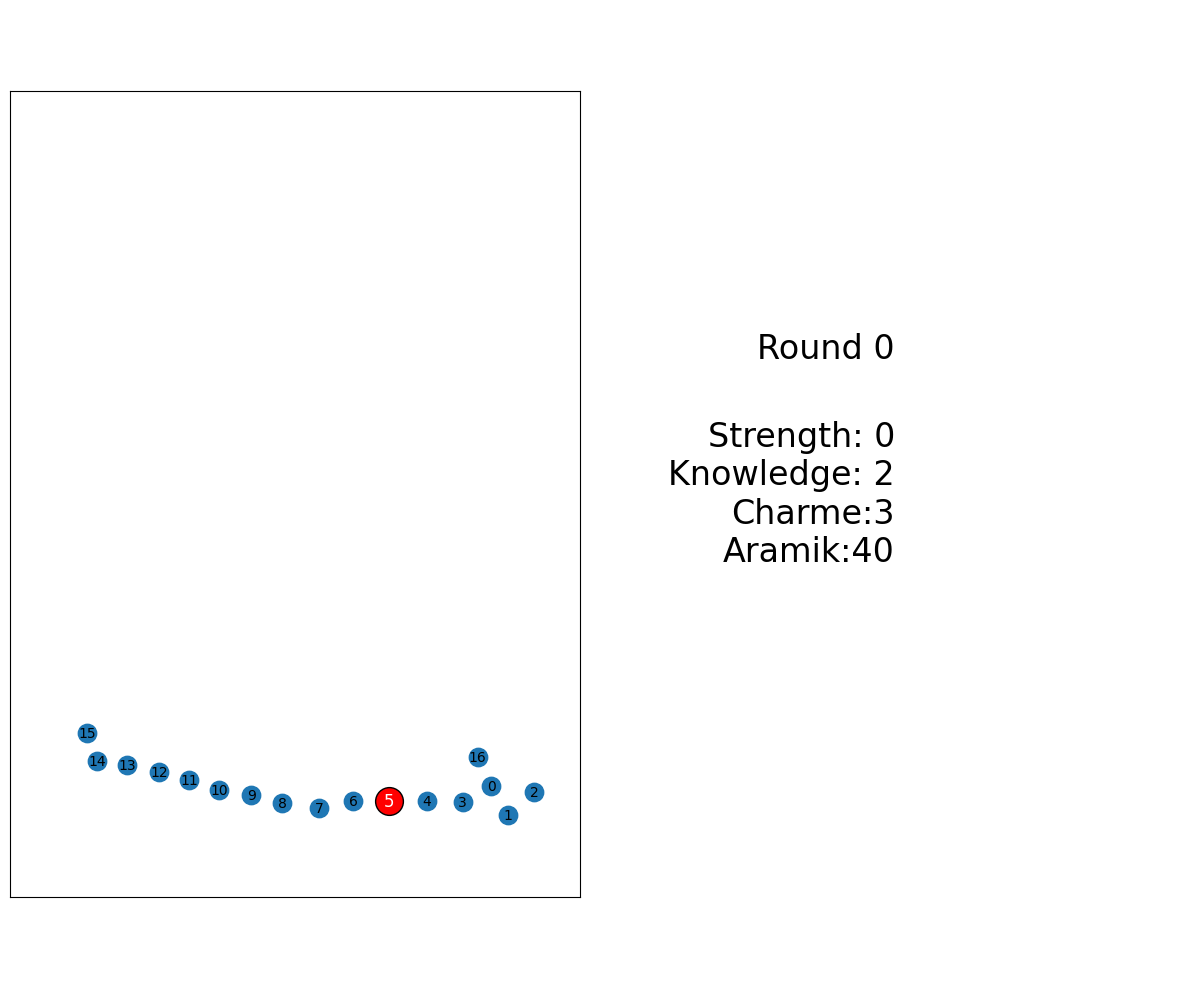

In [9]:
game_state_demo.print_current_game_state()

In [10]:
action = Action(new_node=6, event_name_and_option_text={"event name": "Agons Brücke", "option text": "Den Wegzoll zahlen und die Brücke langsam überqueren"})
game_state_demo = game_state_demo.take_action(action)

[2026-03-15 01:21:18,644] INFO in game_sim: Additional power: 5
[2026-03-15 01:21:18,645] INFO in game_sim: Agons Brücke: Den Wegzoll zahlen und die Brücke langsam überqueren: Positive


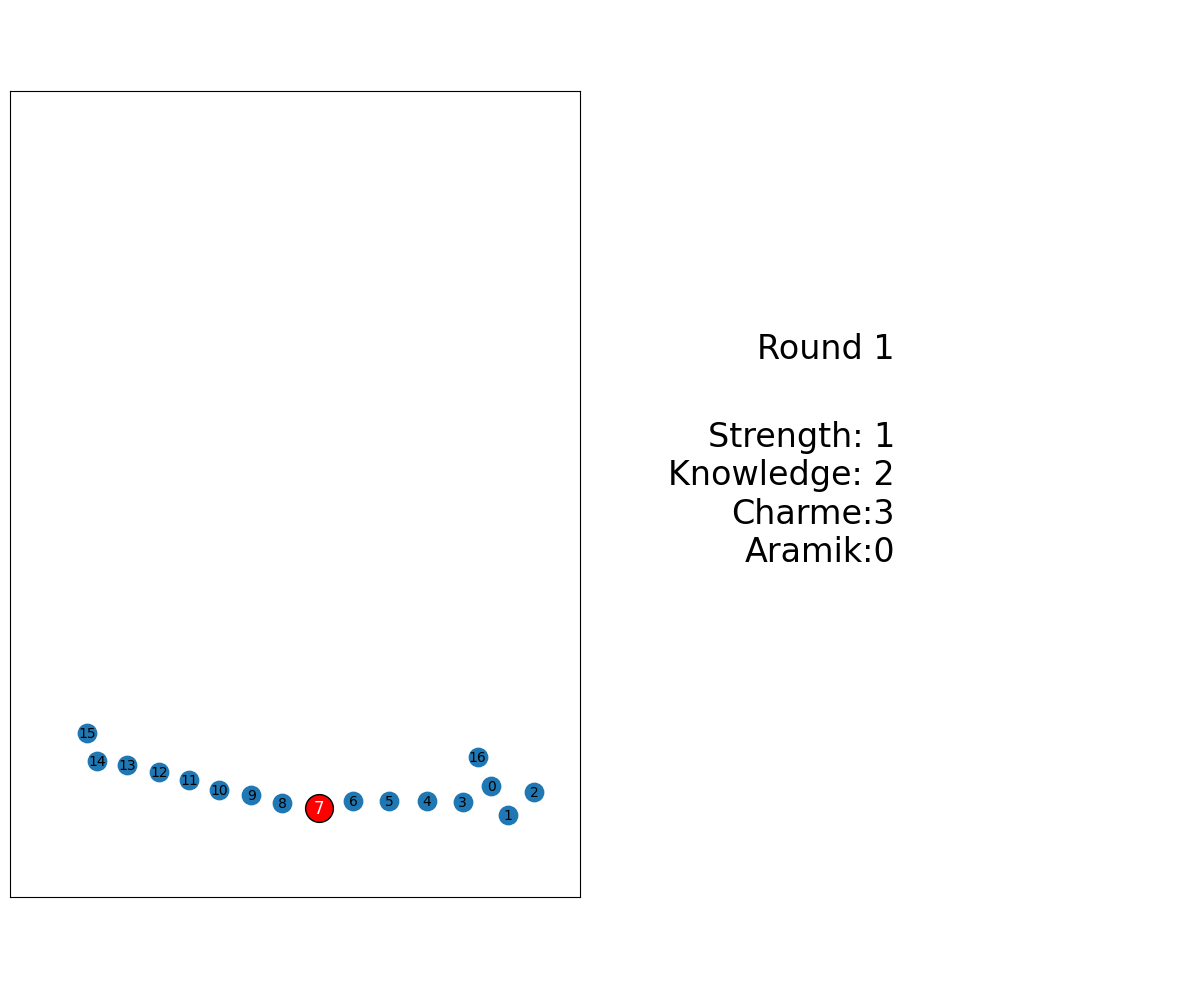

In [11]:
game_state_demo.print_current_game_state()

# Functions to play

In [12]:
def perform_move(
    game_state: GameState, 
    policy 
):
    """
    """
    # Phase 1: rolling dice
    additional_money = random.randint(1, 6) 
    game_state.money = game_state.money + additional_money
    number_of_available_steps = random.randint(1, 6) 

    # Phase 2: Determine legal actions
    # TODO:Should player be able to decide to play less steps than diced
    reachable_nodes = game_state.reachable_within_steps(number_of_available_steps)
    legal_actions = []
    for node in reachable_nodes:
        event_options = game_state.determine_event_options(node)
        for event_option in event_options:
            legal_actions.append((node, event_option))
    print(legal_actions)

    # Phase 3: Take action
    action = policy(game_state, legal_actions)
    game_state = game_state.take_action(action)


# Run simulation

In [13]:
game_trajectory = []
game_state = GameState(start_node=7)

while not game_state.node == 1000:
    game_state, move_trajectory = perform_move(game_state, policy)
    game_trajectory.extend(move_trajectory)


NameError: name 'policy' is not defined